<a href="https://colab.research.google.com/github/kangtayie/Machine-Learning_class/blob/main/auto_mpg_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# 데이터 읽기 + 컬럼명 부여
cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
        'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/auto-mpg.data",
    sep=r'\s+',
    header=None,
    names=cols,
    na_values='?'
)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# 데이터 파악(EDA)
print(df.shape)
print(df.info())
print(df.isnull().sum())   # horsepower 결측치 확인
df.describe()

(398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [4]:
# 전처리(결측치 제거 + 문자열 제거)
df = df.drop('car_name', axis=1)   # 이름은 문자열이라 제외
df = df.dropna()                   # horsepower 결측 행 제거

df.shape

(392, 8)

In [5]:
#  X, y 분리
X = df.drop('mpg', axis=1)
y = df['mpg']

In [6]:
# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# 모델들
models = {
    'Linear': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
}

In [8]:
# 학습+예측+평가
predictions = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name:12s} | MAE={mae:6.2f}  MSE={mse:8.2f}  R2={r2:.3f}")

Linear       | MAE=  2.42  MSE=   10.71  R2=0.790
KNN          | MAE=  2.95  MSE=   17.75  R2=0.652
DecisionTree | MAE=  2.26  MSE=   11.43  R2=0.776
RandomForest | MAE=  1.72  MSE=    5.68  R2=0.889


In [9]:
# regression 리포트 작성
report = pd.DataFrame({
    name: {
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'R2': r2_score(y_test, pred),
    }
    for name, pred in predictions.items()
}).T

report.sort_values('R2', ascending=False)


,MAE,MSE,R2
RandomForest,1.718557,5.680200,0.888712
Linear,2.419780,10.710864,0.790150
DecisionTree,2.259494,11.428481,0.776090
KNN,2.947342,17.752618,0.652186


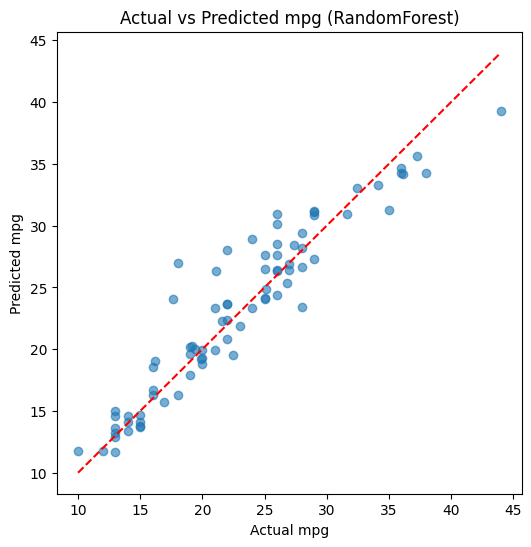

In [10]:
# 시각화(실제값 vs 예측값)
best_model_name = report['R2'].idxmax()
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual mpg')
plt.ylabel('Predicted mpg')
plt.title(f'Actual vs Predicted mpg ({best_model_name})')
plt.show()